In [1]:
import os
import glob
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
#explore variables in the dataset
ds = xr.open_dataset('data/oco2_LtCO2_231231_B11210Ar_240919184624s.nc4')
print(ds)

<xarray.Dataset> Size: 77MB
Dimensions:                 (sounding_id: 169840, epoch_dimension: 7,
                             vertices: 4, levels: 20, bands: 3,
                             source_files: 16, frames: 120142, footprints: 8)
Coordinates:
  * sounding_id             (sounding_id) float64 1MB 2.023e+15 ... 2.023e+15
  * vertices                (vertices) int16 8B 1 2 3 4
  * levels                  (levels) int16 40B 1 2 3 4 5 6 ... 15 16 17 18 19 20
  * bands                   (bands) int16 6B 1 2 3
  * source_files            (source_files) object 128B 'oco2_L2StdGL_50513a_2...
  * frames                  (frames) int32 481kB 1 2 3 ... 120140 120141 120142
  * footprints              (footprints) int16 16B 1 2 3 4 5 6 7 8
Dimensions without coordinates: epoch_dimension
Data variables: (12/20)
    date                    (sounding_id, epoch_dimension) float32 5MB ...
    latitude                (sounding_id) float32 679kB ...
    longitude               (sounding_id) floa

In [ ]:
import os

#Define input and output folders
input_folder = "data"
output_folder = "data_csv"
os.makedirs(output_folder, exist_ok=True)

files = [f for f in os.listdir(input_folder) if f.endswith(".nc4")] #we list all files in the input folder and filter only those with .nc4 extension

for file in files: 
    # Extract the date from the filename 
    date_str = file.split("_")[2]
    year = int("20" + date_str[:2])
    month = int(date_str[2:4])
    day = int(date_str[4:6])
    #open the netcdf file with xarray
    ds = xr.open_dataset(os.path.join(input_folder, file)) #builds the full path  
    #create a dataframe #we convert satellite data into a table  
    df = pd.DataFrame({
        "sounding_id": ds['sounding_id'].values,
        "xco2": ds['xco2'].values, # Column-averaged dry-air CO2 mole fraction : ppm
        "xco2_quality_flag": ds['xco2_quality_flag'].values, #(0: good measurement, 1: bad measurement)
        "latitude": ds['latitude'].values,
        "longitude": ds['longitude'].values,
        "year": year,
        "month": month,
        "day": day
    })
    
    # Filter reliable measurements  
    df = df[df['xco2_quality_flag'] == 0].dropna() # 2 filters : only good measurements and remove missing values
    # Save the csv
    output_file = os.path.join(output_folder, file.replace(".nc4",".csv"))
    df.to_csv(output_file, index=False) #we  save ! (we don't want to save the index as a column in the csv)
    # Close the dataset : for memory management
    ds.close()

print(f"{len(files)} fichiers convertis en CSV et sauvegardés dans {output_folder}")

In [ ]:
df

,sounding_id,xco2,xco2_quality_flag,latitude,longitude,year,month,day
0,2.024123e+15,423.250610,0.0,-22.099403,-154.880325,2024,12,31
3,2.024123e+15,423.017517,0.0,-22.090338,-154.889999,2024,12,31
5,2.024123e+15,423.351318,0.0,-22.109705,-154.901047,2024,12,31
6,2.024123e+15,423.307251,0.0,-22.119268,-154.906677,2024,12,31
7,2.024123e+15,423.729279,0.0,-22.128830,-154.912415,2024,12,31
...,...,...,...,...,...,...,...,...
174704,2.024123e+15,424.296204,0.0,29.299301,-153.633972,2024,12,31
174705,2.024123e+15,423.988892,0.0,29.286909,-153.624268,2024,12,31
174707,2.024123e+15,424.358246,0.0,29.329588,-153.649567,2024,12,31
174713,2.024123e+15,424.494659,0.0,29.310373,-153.626266,2024,12,31


In [ ]:
#read all the csv files and concatenate them into a single dataframe

csv_files = [os.path.join(output_folder, f) for f in os.listdir(output_folder) if f.endswith(".csv")] #csv_files becomes a list of file paths for all csv files in the output folder
df_list = [] #will store all the dataframes read from the csv files #df_list = [ dataframe_day1,dataframe_day2,dataframe_day3,...]
for f in csv_files:
    df = pd.read_csv(f)
    df_list.append(df) # df_list is a python list that contains many dataframes 

df_all = pd.concat(df_list, ignore_index=True) # df_all is a single dataframe that contains one big merged table with all the data from the csv files  
print("Total observations:", len(df_all))
print(df_all.head())

# Check distribution by months
print(df_all["month"].value_counts().sort_index())

Total observations: 29629272
    sounding_id       xco2  xco2_quality_flag   latitude  longitude  year  \
0  2.023123e+15  421.54187                0.0  14.950292 -160.42061  2023   
1  2.023123e+15  421.45493                0.0  14.939731 -160.41380  2023   
2  2.023123e+15  421.16208                0.0  14.929037 -160.40704  2023   
3  2.023123e+15  421.64328                0.0  14.918242 -160.40036  2023   
4  2.023123e+15  420.92540                0.0  14.907461 -160.39381  2023   

   month  day  
0     12   31  
1     12   31  
2     12   31  
3     12   31  
4     12   31  
month
1     2558975
2     2333475
3     1965942
4     2182489
5     2306730
6     2364216
7     2569182
8     2732078
9     2885393
10    2820369
11    2487599
12    2422824
Name: count, dtype: int64


In [ ]:
df_all

,sounding_id,xco2,xco2_quality_flag,latitude,longitude,year,month,day
0,2.023123e+15,421.54187,0.0,14.950292,-160.42061,2023,12,31
1,2.023123e+15,421.45493,0.0,14.939731,-160.41380,2023,12,31
2,2.023123e+15,421.16208,0.0,14.929037,-160.40704,2023,12,31
3,2.023123e+15,421.64328,0.0,14.918242,-160.40036,2023,12,31
4,2.023123e+15,420.92540,0.0,14.907461,-160.39381,2023,12,31
...,...,...,...,...,...,...,...,...
29629267,2.024123e+15,424.29620,0.0,29.299301,-153.63397,2024,12,31
29629268,2.024123e+15,423.98890,0.0,29.286910,-153.62427,2024,12,31
29629269,2.024123e+15,424.35825,0.0,29.329588,-153.64957,2024,12,31
29629270,2.024123e+15,424.49466,0.0,29.310373,-153.62627,2024,12,31


In [ ]:
#Filtrer pour l'Afrique
# -----------------------------
df_africa = df_all[
    (df_all["latitude"] >= -40) & (df_all["latitude"] <= 40) & # Africa is between 35°S and 37°N
    (df_all["longitude"] >= -20) & (df_all["longitude"] <= 60) # Africa is between 17°W and 51°E
]
print("Observations en Afrique:", len(df_africa))
# NB : It is not the exact shape of Africa but just a geographical box that contains the continent. We will refine this later with a shapefile of Africa.

Observations en Afrique: 5194776


In [ ]:
#To create a map, we will transform the data into a grid!
#Create grid coordinates
df_africa['lat_grid'] = df_africa['latitude'].round() #it rounds the latitude to the nearest integer : 12.13 => 12 
df_africa['lon_grid'] = df_africa['longitude'].round()

grid_co2 = df_africa.groupby(['lat_grid','lon_grid'])['xco2'].mean().reset_index() # we group the data by lat_grid and lon_grid and calculate the mean xco2 for each grid cell 

print(grid_co2.head())
print(grid_co2.shape) # (number of grid cells, number of columns: 6270, 3)

co2_xr = grid_co2.to_xarray()

   lat_grid  lon_grid        xco2
0     -40.0     -19.0  418.407747
1     -40.0     -18.0  418.445086
2     -40.0     -17.0  418.396280
3     -40.0     -16.0  418.848523
4     -40.0     -15.0  418.996627
(6270, 3)


In [ ]:
import geopandas as gpd
africa_shp = gpd.read_file("data_shapefile/ne_110m_admin_0_countries.shp") # loads the shapefile of countries  
africa = africa_shp[africa_shp["CONTINENT"] == "Africa"] # keep only africa     

In [ ]:
#grid_df = co2_xr = grid_co2.to_xarray() 
from shapely.geometry import Point

grid_co2["geometry"] = grid_co2.apply(
    lambda row: Point(row["lon_grid"], row["lat_grid"]),
    axis=1
)

gdf_grid = gpd.GeoDataFrame(grid_co2, geometry="geometry", crs="EPSG:4326")

In [ ]:
gdf_africa_clipped = gpd.clip(gdf_grid, africa)

print(len(gdf_africa_clipped))

2343


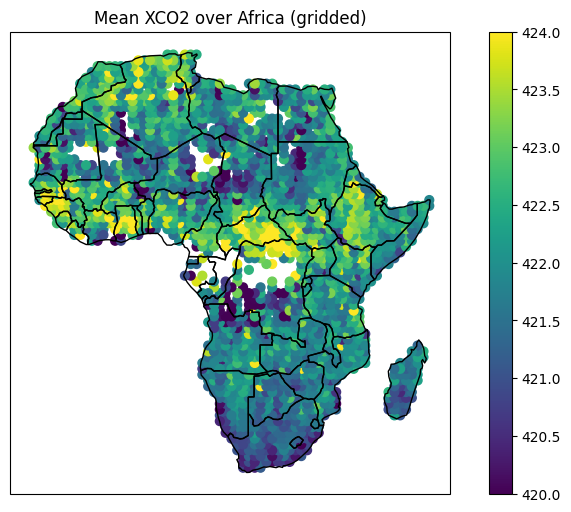

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10,6), subplot_kw={"projection": ccrs.PlateCarree()})

gdf_africa_clipped.plot(
    ax=ax,
    column="xco2",
    cmap="viridis",
    markersize=40,
    vmin=420,
    vmax=424,
    legend=True
)

# Frontières de l’Afrique
africa.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    transform=ccrs.PlateCarree()
)
#ax.set_extent([-20, 60, -40, 40], crs=ccrs.PlateCarree())

ax.set_title("Mean XCO2 over Africa (gridded)")
plt.show()

In [ ]:
from shapely.geometry import box

grid_co2["geometry"] = grid_co2.apply(
    lambda row: box(
        row["lon_grid"] - 0.5,
        row["lat_grid"] - 0.5,
        row["lon_grid"] + 0.5,
        row["lat_grid"] + 0.5
    ),
    axis=1
)

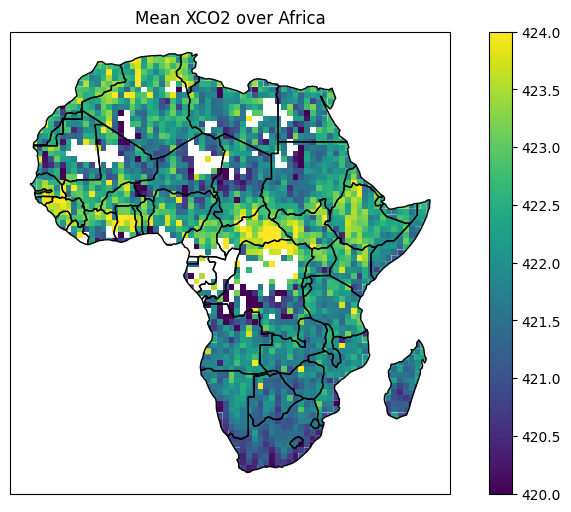

In [ ]:
gdf_grid = gpd.GeoDataFrame(grid_co2, geometry="geometry", crs="EPSG:4326")
gdf_africa_clipped = gpd.clip(gdf_grid, africa)
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={"projection": ccrs.PlateCarree()})

gdf_africa_clipped.plot(
    ax=ax,
    column="xco2",
    cmap="viridis",
    vmin=420,
    vmax=424,
    legend=True
)

africa.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("Mean XCO2 over Africa")

plt.show()

In [ ]:
months = range(1, 13)
for m in months:
    df_month = df_all[df_all['month'] == m]
    print(f"Month {m}: {len(df_month)} observations")

In [ ]:
print(df_all.columns)

Index(['sounding_id', 'xco2', 'xco2_quality_flag', 'latitude', 'longitude',
       'year', 'month', 'day'],
      dtype='str')


In [ ]:
monthly_co2 = df_africa.groupby('month')['xco2'].mean()
print(monthly_co2)

month
1     420.811428
2     421.160386
3     421.585288
4     421.599144
5     421.654182
6     422.189805
7     422.114629
8     421.649816
9     421.215491
10    421.769202
11    422.595504
12    423.427389
Name: xco2, dtype: float64


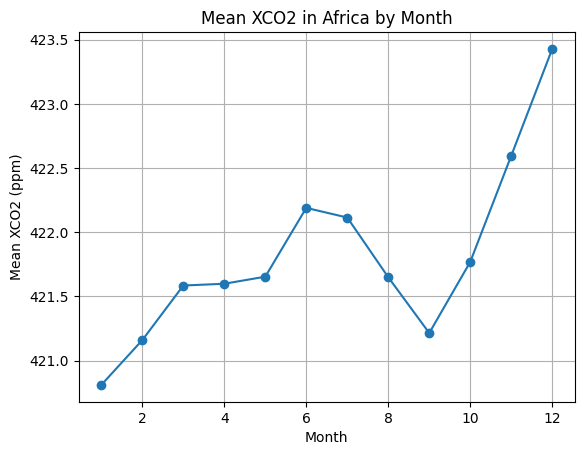

In [ ]:
monthly_co2.plot(marker='o')
plt.xlabel("Month")
plt.ylabel("Mean XCO2 (ppm)")
plt.title("Mean XCO2 in Africa by Month")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs

# Load Africa shapefile
africa_shp = gpd.read_file("data_shapefile/ne_110m_admin_0_countries.shp")
africa = africa_shp[africa_shp["CONTINENT"] == "Africa"]

# Round latitude and longitude to create grid
df_africa['lat_grid'] = df_africa['latitude'].round()
df_africa['lon_grid'] = df_africa['longitude'].round()

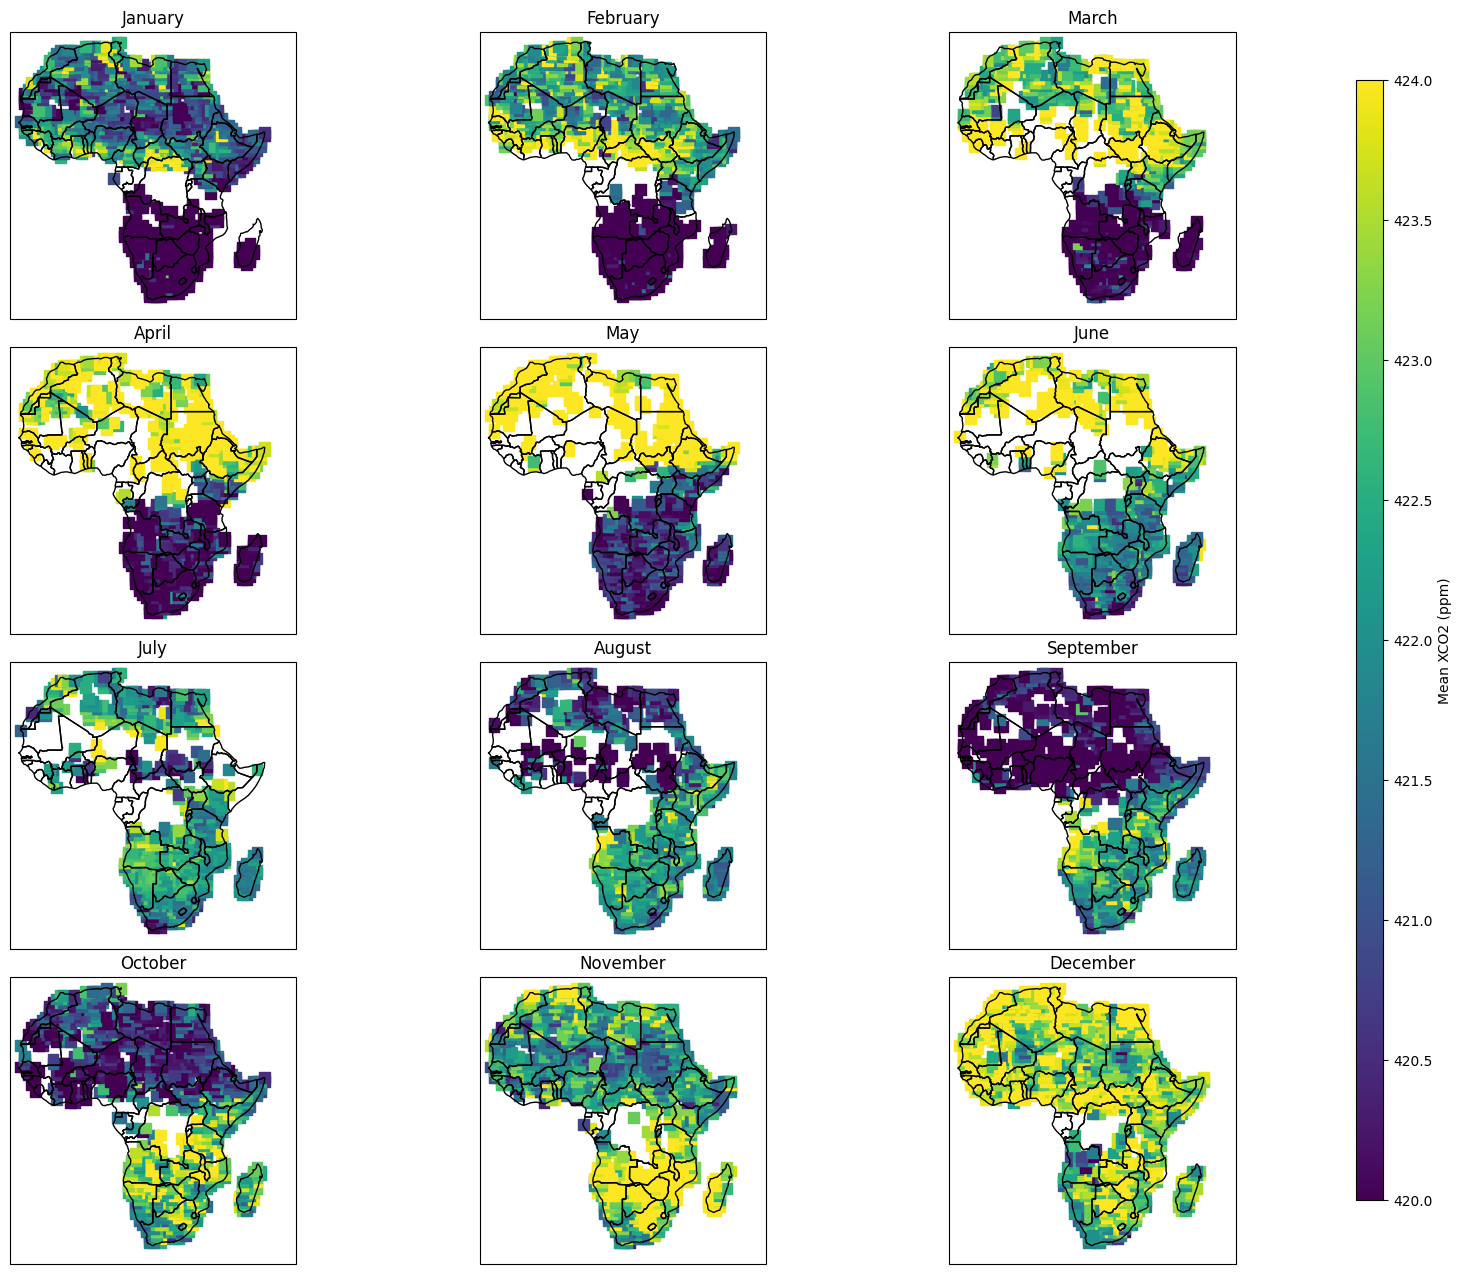

In [ ]:
from matplotlib.gridspec import GridSpec

month_names = ['January','February','March','April','May','June','July','August','September','October','November','December']

# Create figure with GridSpec: 4 rows x 3 columns
fig = plt.figure(figsize=(18, 16))
gs = GridSpec(4, 3, figure=fig, wspace=0.03, hspace=0.1)  # less horizontal space

axes = []
for i in range(12):
    ax = fig.add_subplot(gs[i], projection=ccrs.PlateCarree())
    axes.append(ax)


# Loop over months
for month in range(1, 13):
    df_month = df_africa[df_africa['month'] == month]
    
    # Gridded mean
    grid_month = df_month.groupby(['lat_grid', 'lon_grid'])['xco2'].mean().reset_index()
    grid_month['geometry'] = grid_month.apply(lambda row: Point(row['lon_grid'], row['lat_grid']), axis=1)
    gdf_grid = gpd.GeoDataFrame(grid_month, geometry='geometry', crs="EPSG:4326")
    
    # Clip to Africa
    gdf_clipped = gpd.clip(gdf_grid, africa)
    
    # Plot squares
    ax = axes[month-1]
    gdf_clipped.plot(
        ax=ax,
        column='xco2',
        cmap='viridis',
        markersize=60,
        marker='s',
        vmin=420,
        vmax=424,
        legend=False
    )
    
    africa.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    ax.set_title(month_names[month-1])
    ax.set_extent([-20, 60, -40, 40], crs=ccrs.PlateCarree())
    

# Add a single colorbar on the right
import matplotlib as mpl
sm = plt.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=420, vmax=424))
sm._A = []
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Mean XCO2 (ppm)')

plt.show()

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

df_africa["season"] = df_africa["month"].apply(get_season)

C:\Users\USER\AppData\Local\Temp\ipykernel_19108\1421648495.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


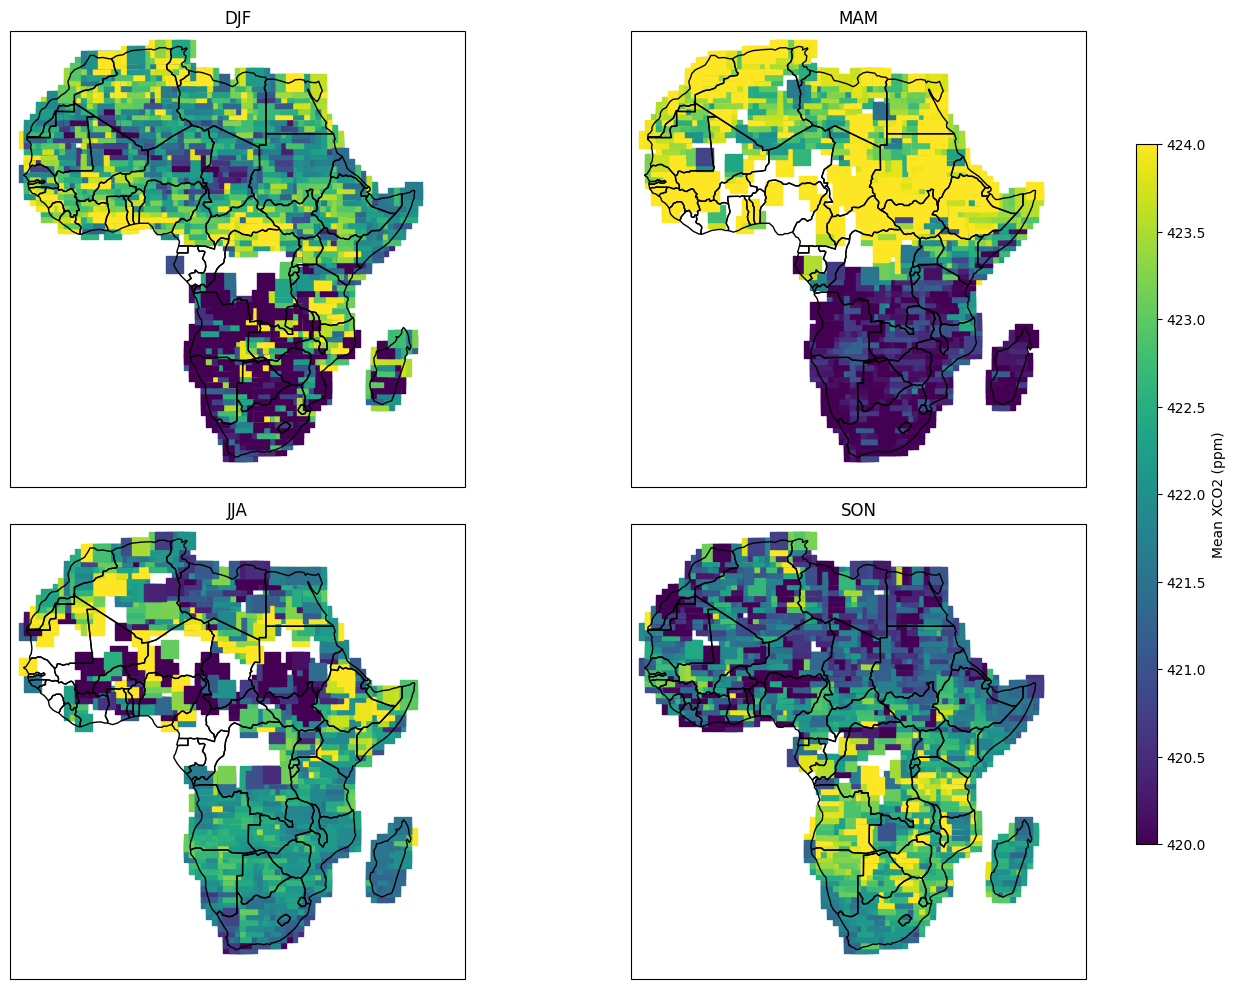

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(14,10),
                         subplot_kw={'projection': ccrs.PlateCarree()})

axes = axes.flatten()
seasons = ["DJF","MAM","JJA","SON"]
for i, season in enumerate(seasons):

    df_season = df_africa[df_africa["season"] == season]

    # grid average
    grid_season = df_season.groupby(['lat_grid','lon_grid'])['xco2'].mean().reset_index()

    grid_season['geometry'] = grid_season.apply(
        lambda row: Point(row['lon_grid'], row['lat_grid']), axis=1)

    gdf_grid = gpd.GeoDataFrame(grid_season, geometry='geometry', crs="EPSG:4326")

    # clip Africa
    gdf_clipped = gpd.clip(gdf_grid, africa)

    ax = axes[i]

    gdf_clipped.plot(
        ax=ax,
        column='xco2',
        cmap='viridis',
        marker='s',
        markersize=150,
        vmin=420,
        vmax=424,
        legend=False
    )

    africa.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

    ax.set_title(season)
    ax.set_extent([-20,60,-40,40], crs=ccrs.PlateCarree())

    ax.set_xticks([])
    ax.set_yticks([])


import matplotlib as mpl
sm = plt.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(vmin=420, vmax=424))
sm._A = []
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Mean XCO2 (ppm)')

plt.tight_layout()
plt.show()

In [ ]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 2.8 MB/s eta 0:00:13
    --------------------------------------- 0.8/36.5 MB 2.8 MB/s eta 0:00:13
    --------------------------------------- 0.8/36.5 MB 2.8 MB/s eta 0:00:13
   - -------------------------------------- 1.0/36.5 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.3/36.5 MB 1.3 MB/s eta 0:00:27
   -- ------------------------------------- 1.8/36.5 MB 1.3 MB/s eta 0:00:27
   -- ------------------------------------- 1.8/36.5 MB 1.3 MB/s eta 0:00:27
   -- ------------------------------------- 2.1/36.5 MB 1.2 MB/s eta 0:00:28
   -- ------------------------------------- 2.4/36.5 MB 1.2 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/36.5 MB 1.2 MB/s eta 0:00:28
   --- -----


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\rasterio\plot.py:375: RuntimeWarning: invalid value encountered in divide
  return (band - imin) / (imax - imin)


MemoryError: Unable to allocate 8.58 MiB for an array with shape (1125000,) and data type float64

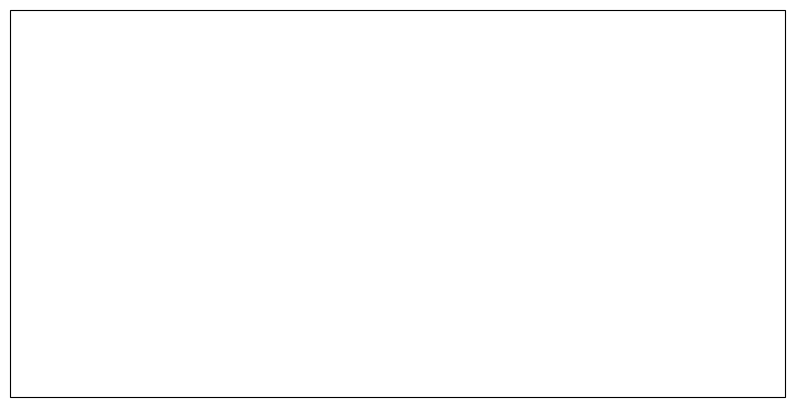

In [ ]:
import rasterio
from rasterio.plot import show
from rasterio.windows import from_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load Africa shapefile and get bounds
africa_shp = gpd.read_file("data_shapefile/ne_110m_admin_0_countries.shp")
africa = africa_shp[africa_shp["CONTINENT"] == "Africa"]
minx, miny, maxx, maxy = africa.total_bounds  # Africa extent

# Open raster
landcover_path = "data_raster/land_cover_africa.tif"
with rasterio.open(landcover_path) as src:
    # Read only the Africa window
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    lc_africa = src.read(1, window=window, out_shape=(500, 500))  # downsample to 500x500 for plotting
    transform = src.window_transform(window)

# Plot
fig, ax = plt.subplots(figsize=(10,8), subplot_kw={"projection": ccrs.PlateCarree()})

# Land-cover background
show(lc_africa, ax=ax, transform=transform, cmap='terrain', alpha=0.6)

# Overlay gridded XCO2
gdf_africa_clipped.plot(
    ax=ax,
    column='xco2',
    cmap='viridis',
    markersize=6,
    vmin=420,
    vmax=424,
    legend=True
)

# Africa borders
africa.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Annual XCO2 over Africa with Land Cover (resampled)")
plt.show()

MemoryError: Unable to allocate 2.81 GiB for an array with shape (21175, 17792) and data type float64

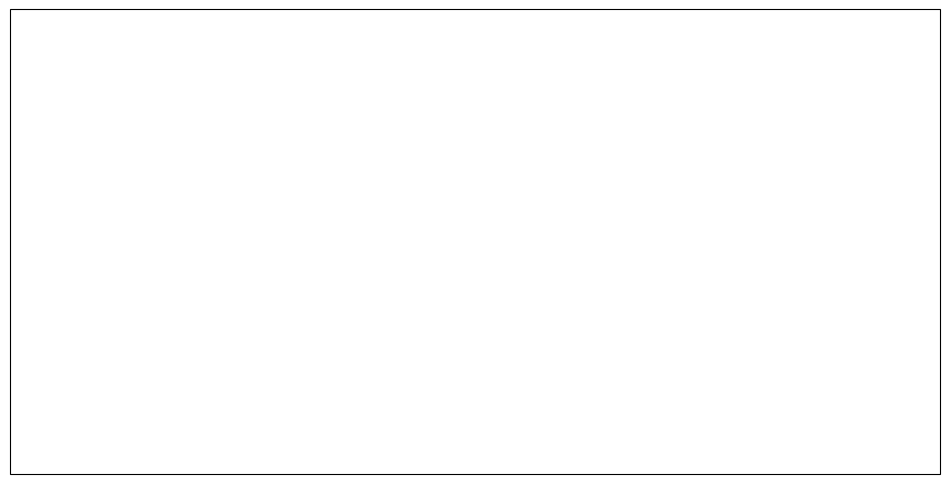

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Open the landcover raster
lc_raster = rasterio.open("data_raster/land_cover_africa.tif")

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot raster with correct extent
show(lc_raster, ax=ax, transform=ccrs.PlateCarree(), cmap='terrain', alpha=0.6, extent=[-20, 60, -40, 40])

ax.set_title("Land Cover Africa (2024)")
plt.show()